# Fit of the VCA with magnetic end springs

Fits a nonlinear model to the chirp data in `data/train` and `data/test`

$$m\ddot{x} = \Gamma (x)\, i - c\,\dot{x} - F_s(x),$$

where $m$ is the shaft mass, $\Gamma(x)$ is the transduction coefficient, $i$ is the input current, $c$ is the friction, and $F_s$ is the restoring force exerted the magnets.

**Strategy.** 
1. Three methods are fitted. Method A and B use a cubic polynomial for the restoring force and a position dependent transduction coefficient. However, method B uses a quadratic transduction equation as given in the actuator datasheet. Method C uses an inverse cubic fit and assumes unequal magnets.
2. All methods are fitted using linear least squares as all models are linear in their parameters.

**Discrete-time model.** RK4 with $T_s$ = 1 ms (log at 2 kHz, every other sample kept) and zero-order-hold input. Predictions start from the measured $(x, \dot{x})$; models are compared on position NRMSE against prediction horizon.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import signal
from scipy.optimize import least_squares, lsq_linear

sns.set_theme(style="whitegrid")

FS_LOG, DECIM = 2000.0, 2
TS = 1/1000.0                       # discretization inter-sampling time
M = 51.5                            # kg
GAMMA0, C0 = 283.0, 1700.0          # datasheet; iteration
CMU0, G00 = 2.423, 22.3e-3          # PDF eq. 13; measured gap in experiment
s_ds = lambda x: (283 - 0.0198 * (x * 1e3) - 0.578 * (x * 1e3)**2) / 283   # datasheet K_f(z) shape, z in mm, 1 at the centre
LF_MAX, HF_MIN = 5.0, 37.0          # Hz; Low freq range and high freq range, ub and lb (37 Hz: above the 35.5 Hz laser-mount mode)
H_FIT, H_EVAL, STRIDE = 500, 500, 10 # steps for fitting the data
FOH = False                         # Zero-order hold
TAU = 0.65e-3                       # s, position is logged this much later than the commanded current (tuned on actual current: retune); undone in load
TAU_ACC = 2.65e-3                   # s, accelerometer is logged this much later than the commanded current (tuned on actual current: retune); undone in load
T_CUT = 5.0                         # s, end of each run left out of the HF band
ACC_SCALE_V_PER_G = 0.0578 * 0.65   # accelerometer V/g: plot-script 0.0578 corrected by the gain against position above 35 Hz (0.60-0.68)
F_MAX_A = 55.0                      # Hz, Methods A-C use the scheduled chirp up to this frequency (55 = whole run; 34 stays below the 35.5 Hz mode)

b_lp, a_lp = signal.butter(4, 100.0 / (FS_LOG / 2))   # 4th-order 100 Hz low-pass


def load(path):
    "Read one log; return filtered current, position and acceleration at 1 kHz (t >= 0), velocity, and band masks."
    # chirp start/end frequency and duration from the file name, e.g. ..._1.0to55.0Hz_120.0s_...
    m = re.search(r"_([\d.]+)to([\d.]+)Hz_([\d.]+)s_", path.name)
    f0, f1, T = map(float, m.groups()) if m else (np.nan,) * 3   # no chirp in the name (e.g. PRBS): band masks are empty
    raw = np.loadtxt(path, delimiter=",", skiprows=2)   # skip header and the duplicate first row
    lp = lambda s: signal.filtfilt(b_lp, a_lp, s)       # zero-phase, also the anti-alias filter for decimation
    # columns 0 time_s, 2 target_current_A (commanded, sent over EtherCAT), 11 position_mm, 12 ai2_corrected_V (bias removed in firmware)
    t = raw[:, 0]
    x = np.interp(t + TAU, t, lp(raw[:, 11] * 1e-3))   # shift position back by TAU to align it with the current
    for f_n in (50.0, 150.0):                           # mains pickup in the laser signal
        x = signal.filtfilt(*signal.iirnotch(f_n, 30.0, fs=FS_LOG), x)
    a = (np.interp(t + TAU_ACC, t, lp(raw[:, 12])) / ACC_SCALE_V_PER_G * 9.81 if raw.shape[1] > 12   # measured acceleration, shifted back by TAU_ACC
         else np.full(len(t), np.nan))                          # older logs have no ai2_corrected_V
    keep = slice(np.searchsorted(t, 0.0), None, DECIM)  # drop the t < 0 idle window, 2 kHz -> 1 kHz
    d = dict(t=t[keep], i=lp(raw[:, 2])[keep], x=x[keep], a_meas=a[keep])
    d["v"] = np.gradient(d["x"], TS)                    # velocity: initial states and LLS
    d["a_x"] = np.gradient(d["v"], TS)                  # acceleration from position
    d["a"] = d["a_x"]                                   # fits use position-derived acceleration; accelerometer only plotted
    f = f0 * (f1 / f0) ** (d["t"] / T)                  # instantaneous frequency of the exponential chirp
    d["lf"] = f <= LF_MAX                               # old low band, used by methods B-D
    d["hf"] = (f >= HF_MIN) & (d["t"] <= d["t"][-1] - T_CUT)
    d["sweep"] = f <= F_MAX_A                           # Methods A-C window: scheduled chirp from its start up to F_MAX_A
    return d


def step(x, v, u0, u1, acc, ts=TS):
    "One RK4 step, length ts, of (x, v) with input u0 at the start and u1 at the end of the step."
    um = 0.5 * (u0 + u1)
    k1x, k1v = v, acc(x, v, u0)
    k2x, k2v = v + ts / 2 * k1v, acc(x + ts / 2 * k1x, v + ts / 2 * k1v, um)
    k3x, k3v = v + ts / 2 * k2v, acc(x + ts / 2 * k2x, v + ts / 2 * k2v, um)
    k4x, k4v = v + ts * k3v, acc(x + ts * k3x, v + ts * k3v, u1)
    return x + ts / 6 * (k1x + 2 * k2x + 2 * k3x + k4x), v + ts / 6 * (k1v + 2 * k2v + 2 * k3v + k4v)


def rollout(Fs, p, d, s, H):
    "Predicted x, shape (len(s), H+1), from the measured state at each start index s. p = [Gamma, c, *spring]."
    acc = lambda x, v, u: (p[0] * u - p[1] * v - Fs(x, u, p[2:])) / M      # Fs gets the current too, for Gamma(x)
    x, v, out = d["x"][s], d["v"][s], [d["x"][s]]
    with np.errstate(all="ignore"):
        for k in range(H):
            u0 = d["i"][s + k]
            x, v = step(x, v, u0, d["i"][s + k + 1] if FOH else u0, acc)
            out.append(x)
    return np.stack(out, axis=1)


def starts(d, band, H):
    "Every STRIDE-th sample of the band whose H-step horizon fits in the record."
    s = np.flatnonzero(band)[::STRIDE]
    return s[s + H < len(d["x"])]


def target(d, s, H):
    "Measured x over the horizon of each start, shape (len(s), H+1)."
    return d["x"][s[:, None] + np.arange(H + 1)]


def fit(Fs, p0, d, band, lb=-np.inf, free=slice(None), detrend=False):
    "H-step-ahead fit of p0[free]; detrend removes per-start mean and slope of the error (free-mass drift)."
    s = starts(d, band, H_FIT)
    X = target(d, s, H_FIT)[:, 1:]
    p = np.array(p0, float)
    def res(q):
        p[free] = q
        e = np.nan_to_num(rollout(Fs, p, d, s, H_FIT)[:, 1:], nan=1.0, posinf=1.0, neginf=-1.0) - X   # diverged rollout -> 1 m
        return (signal.detrend(e, axis=1) if detrend else e).ravel()
    r = least_squares(res, p[free], x_scale=np.abs(p[free]), bounds=(lb, np.inf))
    p[free] = r.x
    print(f"{r.message} ({r.nfev} evaluations)")
    return p


def nrmse_curve(Fs, p, d, band, H=H_EVAL):
    "Position RMS error per horizon step, normalised by the std of x in the band."
    s = starts(d, band, H)
    e = rollout(Fs, p, d, s, H) - target(d, s, H)
    return np.sqrt(np.mean(e ** 2, axis=0)) / np.std(d["x"][band])


CURVES = []

def evaluate(name, Fs, p, exp, band, H=H_EVAL):
    "Left: NRMSE against horizon, train and test. Right: one H-step prediction on test, started mid-band."
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    k = np.arange(1, H + 1)
    for split, d in DATA[exp].items():
        e = nrmse_curve(Fs, p, d, d[band], H)[1:]
        CURVES.append(dict(method=name, split=split, exp=exp, band=band, k=k, nrmse=e))   # kept for the comparison cell
        sns.lineplot(x=k, y=e, ax=ax[0], label=split)
        print(f"{split:5s} NRMSE at k = 1, 10, 100, {H}: " + ", ".join(f"{e[j - 1]:.3f}" for j in (1, 10, 100, H)))
    ax[0].set(xscale="log", xlabel="steps ahead (1 step = 1 ms)", ylabel="position NRMSE", title=f"{name}, {band.upper()} band")
    d = DATA[exp]["test"]
    s0 = starts(d, d[band], H)
    s0 = s0[len(s0) // 2:][:1]                          # one start in the middle of the band
    t = d["t"][s0[0]:s0[0] + H + 1]
    sns.lineplot(x=t, y=target(d, s0, H)[0] * 1e3, ax=ax[1], label="measured", color="k")
    sns.lineplot(x=t, y=rollout(Fs, p, d, s0, H)[0] * 1e3, ax=ax[1], label="predicted")
    ax[1].set(xlabel="time (s)", ylabel="x (mm)", title=f"test: {H}-step prediction from the measured state")
    plt.tight_layout(); plt.show()


# self-check: undamped linear spring from x = 1 mm must follow cos(wt)
_k = 1e5
_d = dict(x=np.full(2, 1e-3), v=np.zeros(2), i=np.zeros(1000))
_x = rollout(lambda x, u, q: q[0] * x, [0.0, 0.0, _k], _d, np.array([0]), 900)[0]
assert np.allclose(_x, 1e-3 * np.cos(np.sqrt(_k / M) * TS * np.arange(901)), atol=1e-8)

## Stage 0: data

Two experiment types per split, from `data/train` and `data/test`:
- `chirp`: plain chirp, 1→55 Hz, not fitted: used for validation, the Kalman filter and the spectral analysis.
- `chirpsched`: chirp 10→55 Hz with amplitude ramps, for Methods A-C (band `sweep`: from the start up to `F_MAX_A` Hz).

The 3 s idle window (t < 0) is dropped; position is notched at 50 and 150 Hz (mains pickup in the laser). The fits use the position-derived acceleration; the bias-corrected accelerometer `ai2_corrected_V` is only plotted for comparison.

chirp      train a_meas / a_from_x = 1.142
chirp      test  a_meas / a_from_x = 1.106
chirpsched train a_meas / a_from_x = 1.225
chirpsched test  a_meas / a_from_x = 1.242


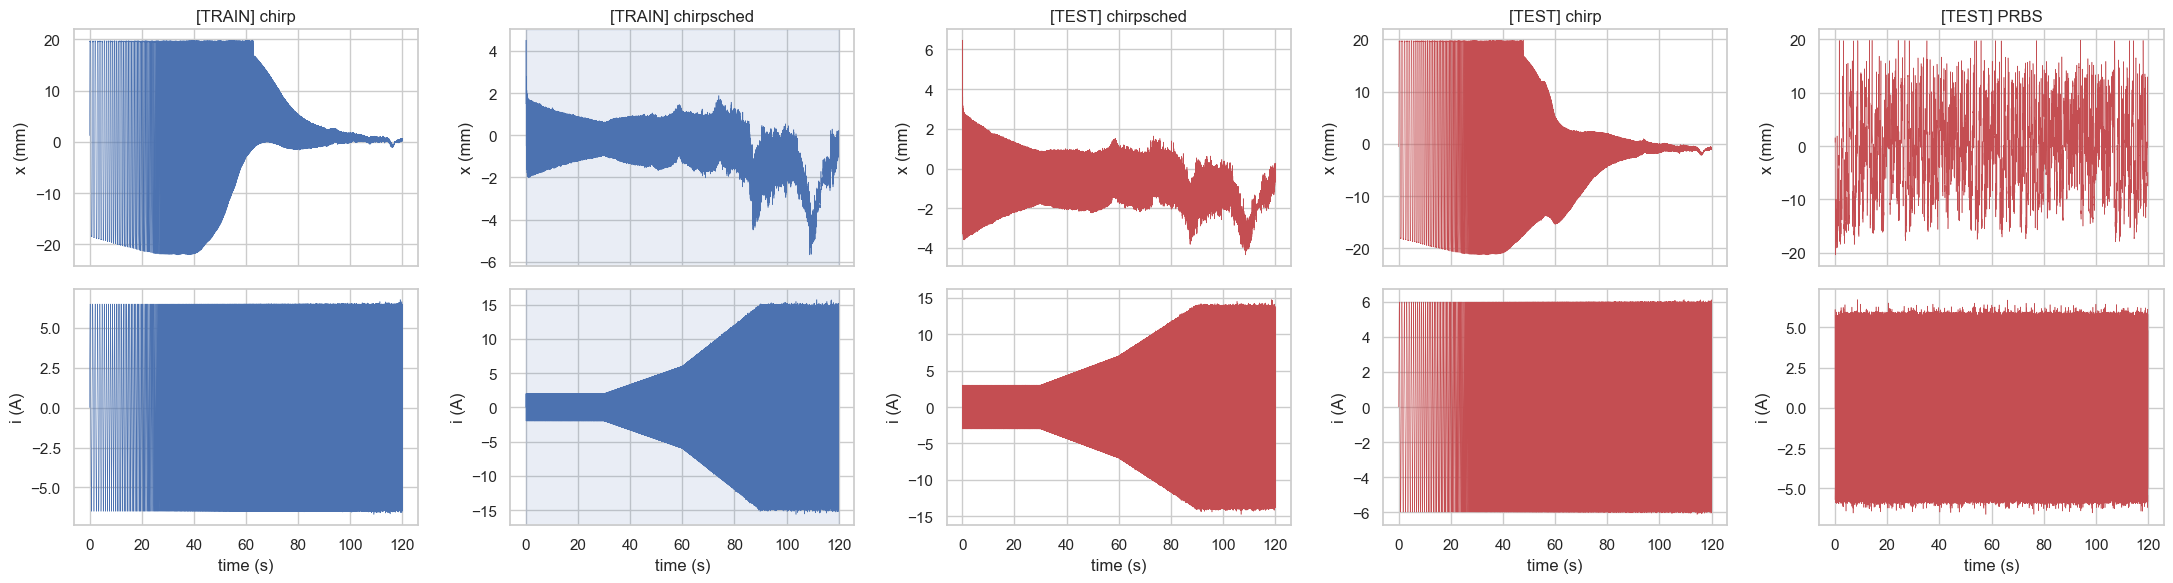

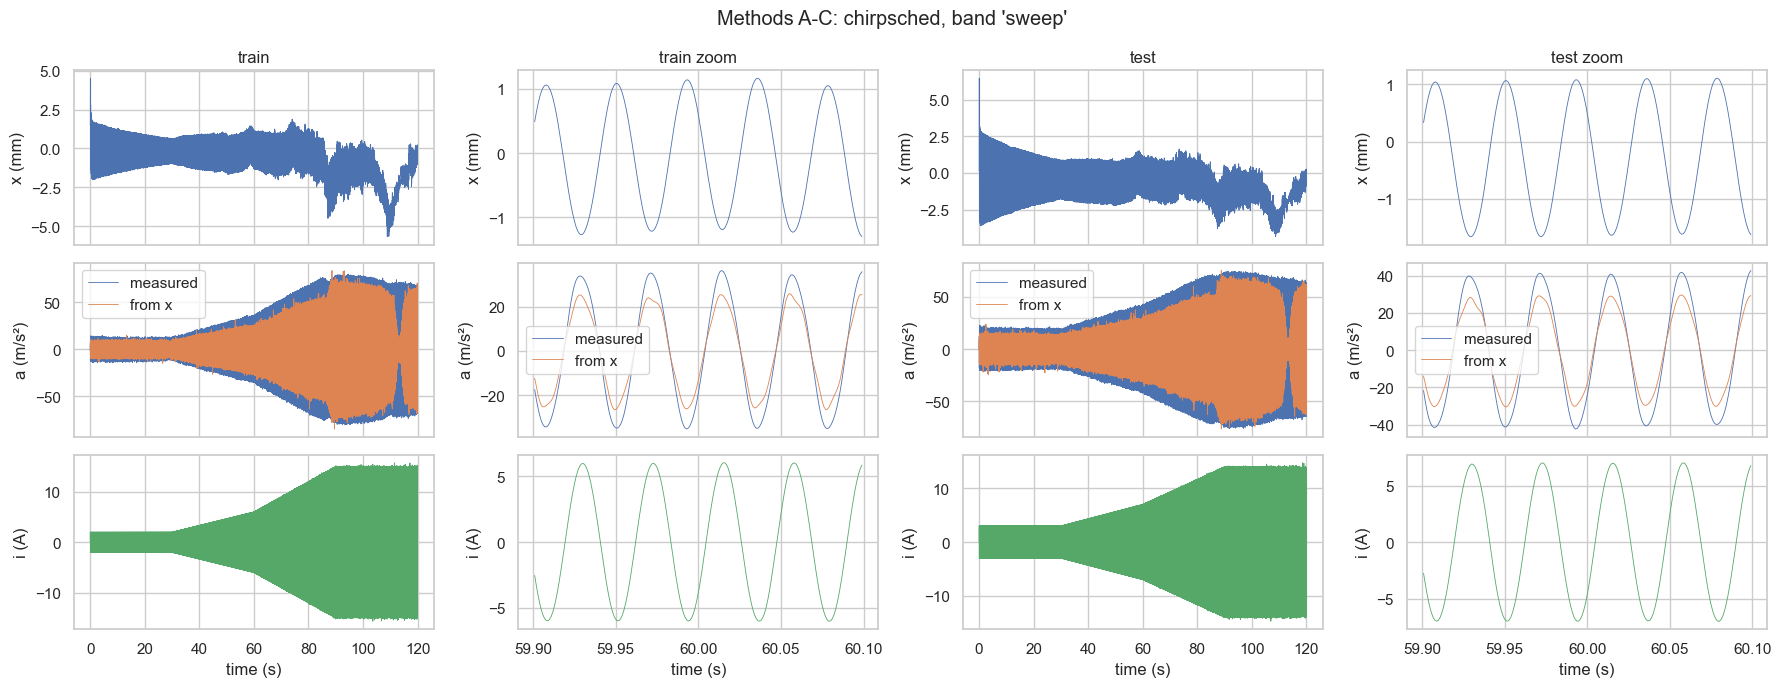

In [2]:
DATA = {exp: {s: load(next(Path("data", s).glob(f"voice_coil_log_{exp}_*.csv"))) for s in ("train", "test")}
        for exp in ("chirp", "chirpsched")}
USE = [("Methods A-C", "chirpsched", "sweep")]

# accelerometer scale check: slope of measured against position-derived acceleration, 1.0 if ACC_SCALE_V_PER_G is right
for exp, runs in DATA.items():
    for split, d in runs.items():
        m = d["hf"] | d["sweep"] if exp == "chirpsched" else d["hf"]
        print(f"{exp:10s} {split:5s} a_meas / a_from_x = {np.polyfit(d['a_x'][m], d['a_meas'][m], 1)[0]:.3f}")

# overview: position (top) and current (bottom) of every run, TRAIN in blue, TEST in red; shaded: the window the fit uses
SETS = [("TRAIN", "chirp", DATA["chirp"]["train"], None),            # (role, name, data, band used by the fit): not fitted, spectral analysis
        ("TRAIN", "chirpsched", DATA["chirpsched"]["train"], "sweep"),  # Methods A-C
        ("TEST", "chirpsched", DATA["chirpsched"]["test"], None),       # validation, Kalman filter
        ("TEST", "chirp", DATA["chirp"]["test"], None),                 # validation, Kalman filter
        ("TEST", "PRBS", load(next(Path("data").glob("voice_coil_log_prbs_*.csv"))), None)]   # validation (23 Sep, +-16 mm: extrapolation)
fig, ax = plt.subplots(2, len(SETS), figsize=(22, 6), sharex="col")
for col, (role, name, d, band) in enumerate(SETS):
    color = "C0" if role == "TRAIN" else "C3"
    sns.lineplot(x=d["t"], y=d["x"] * 1e3, ax=ax[0, col], lw=0.4, color=color).set(title=f"[{role}] {name}", ylabel="x (mm)")
    sns.lineplot(x=d["t"], y=d["i"], ax=ax[1, col], lw=0.4, color=color).set(xlabel="time (s)", ylabel="i (A)")
    if band:
        for a_ in ax[:, col]:
            a_.fill_between(d["t"], 0, 1, where=d[band], transform=a_.get_xaxis_transform(), color=color, alpha=0.12)
plt.tight_layout(); plt.show()

# data actually used, one figure per fit: rows position, acceleration, current;
# columns train (whole window, zoom), test (whole window, zoom). The zoom shows a few cycles mid-window to judge delays.
ZOOM_S = 0.2                                            # s, length of the zoom window
for stage, exp, band in USE:
    fig, ax = plt.subplots(3, 4, figsize=(18, 7), sharex="col")
    for k, (split, d) in enumerate(DATA[exp].items()):
        idx = np.flatnonzero(d[band])
        t_mid = d["t"][idx[len(idx) // 2]]
        for col, m in [(2 * k, d[band]), (2 * k + 1, d[band] & (np.abs(d["t"] - t_mid) <= ZOOM_S / 2))]:
            t = d["t"][m]
            sns.lineplot(x=t, y=d["x"][m] * 1e3, ax=ax[0, col], lw=0.6).set(title=f"{split}{' zoom' if col % 2 else ''}", ylabel="x (mm)")
            sns.lineplot(x=t, y=d["a_meas"][m], ax=ax[1, col], lw=0.6, label="measured")
            sns.lineplot(x=t, y=d["a_x"][m], ax=ax[1, col], lw=0.6, label="from x").set(ylabel="a (m/s²)")
            sns.lineplot(x=t, y=d["i"][m], ax=ax[2, col], lw=0.6, color="C2").set(xlabel="time (s)", ylabel="i (A)")
    fig.suptitle(f"{stage}: {exp}, band '{band}'"); plt.tight_layout(); plt.show()

## Spectral analysis of the plain chirp (raw position)

Raw position of the plain chirp only (`SPLIT` = train or test), read straight from the CSV at the logged 2 kHz (Nyquist 1 kHz): no low-pass, no 50/150 Hz notch, no delay shift, no decimation. Shown up to `F_SHOW` = 300 Hz. Left: spectrogram (short-time Fourier transform, Hann window), frequency against time, which should show the chirp's rising line. Right: Welch PSD (averaged FFT periodograms) in dB.

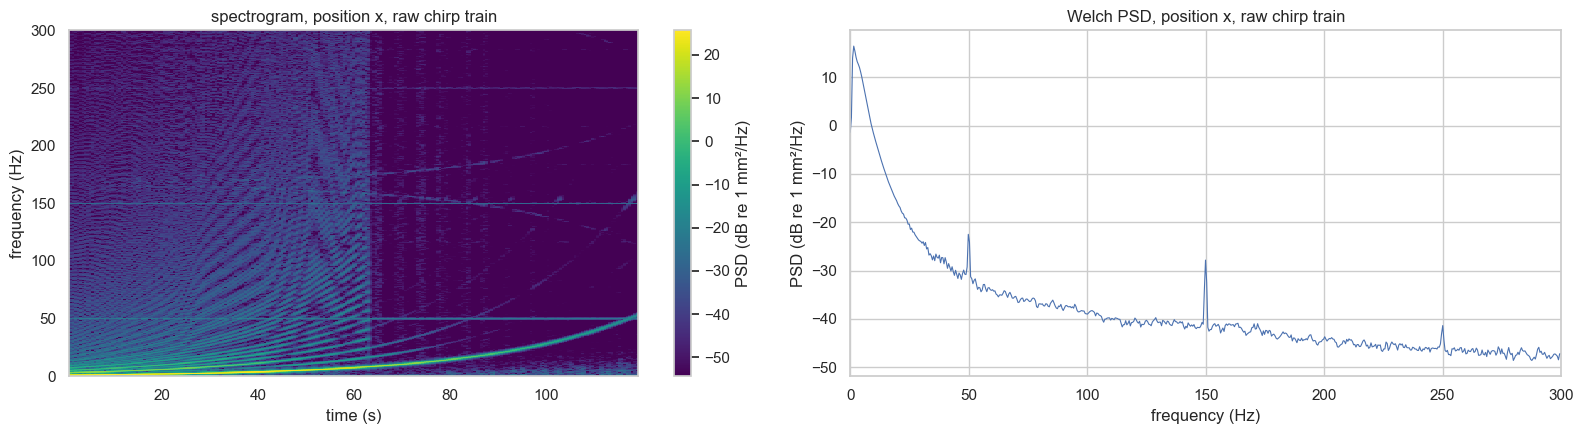

In [3]:
SPLIT = "train"                                         # "train" or "test"
NFFT = 4096                                             # samples per segment: 2.05 s at 2 kHz, 0.49 Hz resolution
F_SHOW = 300.0                                          # Hz, upper plot limit (Nyquist of the raw log is 1 kHz)
path = next(Path("data", SPLIT).glob("voice_coil_log_chirp_*.csv"))   # plain chirp only (chirpsched_ does not match)
raw = np.loadtxt(path, delimiter=",", skiprows=2)       # raw 2 kHz log: no low-pass, no notch, no delay shift, no decimation
x_raw = raw[raw[:, 0] >= 0.0, 11]                       # position_mm, t < 0 idle window dropped

fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
f, t, S = signal.spectrogram(x_raw, fs=FS_LOG, window="hann", nperseg=NFFT, noverlap=NFFT * 3 // 4, detrend="constant", scaling="density")
S_db = 10 * np.log10(S[f <= F_SHOW] + 1e-20)            # colour scale from the shown band only
im = ax[0].pcolormesh(t, f[f <= F_SHOW], S_db, shading="auto", cmap="viridis", vmin=S_db.max() - 80, vmax=S_db.max())
ax[0].set(ylim=(0, F_SHOW), xlabel="time (s)", ylabel="frequency (Hz)", title=f"spectrogram, position x, raw chirp {SPLIT}")
fig.colorbar(im, ax=ax[0], label="PSD (dB re 1 mm²/Hz)")
f, P = signal.welch(x_raw, fs=FS_LOG, window="hann", nperseg=NFFT, noverlap=NFFT // 2, detrend="constant", scaling="density")
sns.lineplot(x=f[f <= F_SHOW], y=10 * np.log10(P[f <= F_SHOW] + 1e-20), ax=ax[1], lw=0.8)   # y-axis autoscales to the shown band
ax[1].set(xlim=(0, F_SHOW), xlabel="frequency (Hz)", ylabel="PSD (dB re 1 mm²/Hz)", title=f"Welch PSD, position x, raw chirp {SPLIT}")
plt.tight_layout(); plt.show()

## Method A: cubic spring, LLS

Polynomial spring with an even term for asymmetry, fitted by bounded linear least squares on the scheduled chirp up to `F_MAX_A` Hz. Each row is divided by the local current amplitude, so the high-current end does not dominate.

$$m\ddot{x} = (\Gamma\,+\,\Gamma_1 x)\, i - c\,\dot{x} - (k_1 x + k_2 x^2 + k_3 x^3)$$

$\Gamma$ and $c$ are fitted together with the spring ($c \geq 0$).

Option (set in the first line of the cell):
- `GAMMA_X = False`: constant motor constant $\Gamma$.
- `GAMMA_X = True`: position-dependent motor constant $\Gamma(x) = \Gamma + \Gamma_1 x$.

Always: $k_3 \geq 0$, so the spring hardens with stroke and keeps its restoring force outside the fitted range.

In [4]:
GAMMA_X = True                                          # position-dependent Gamma(x) = Gamma + Gamma1 x
poly3 = lambda x, u, q: q[-3] * x + q[-2] * x**2 + q[-1] * x**3 - (q[0] * x * u if GAMMA_X else 0.0)   # q = [Gamma1,] k1, k2, k3
d, sel = DATA["chirpsched"]["train"], DATA["chirpsched"]["train"]["sweep"]
x, i, v = d["x"][sel], d["i"][sel], d["v"][sel]
w = 1 / np.abs(signal.hilbert(d["i"]))[sel]                          # 1 / current amplitude, so every part of the sweep counts about equally
cols = {"Gamma": i, "c": -v, **({"Gamma1": x * i} if GAMMA_X else {}),   # m a = Gamma i - c v [+ Gamma1 x i] - (k1 x + k2 x^2 + k3 x^3)
        "k1": -x, "k2": -x**2, "k3": -x**3}
y = M * d["a"][sel]
A = np.column_stack(list(cols.values()))
lb = [0.0 if n in ("c", "k3") else -np.inf for n in cols]           # c >= 0; k3 >= 0: hardening spring
sc = np.linalg.norm(A * w[:, None], axis=0)                          # column scaling
q = dict(zip(cols, lsq_linear(A * w[:, None] / sc, y * w, bounds=(lb, np.inf)).x / sc))
G, c = q.pop("Gamma"), q.pop("c")
p_p3 = np.r_[G, c, list(q.values())]
print(f"Gamma = {G:.1f} N/A, c = {c:.1f} N s/m; " + ", ".join(f"{n} = {val:.4g}" for n, val in q.items()))
if GAMMA_X:
    print("Gamma(x)/Gamma at -5, +5 mm: " + ", ".join(f"{1 + q['Gamma1'] * xx / G:.3f}" for xx in (-5e-3, 5e-3)))

Gamma = 202.0 N/A, c = 1593.6 N s/m; Gamma1 = 4648, k1 = 3.613e+04, k2 = -3.012e+06, k3 = 8.742e-07
Gamma(x)/Gamma at -5, +5 mm: 0.885, 1.115


train NRMSE at k = 1, 10, 100, 1000: 0.003, 0.206, 0.772, 0.694
test  NRMSE at k = 1, 10, 100, 1000: 0.003, 0.190, 0.629, 0.572


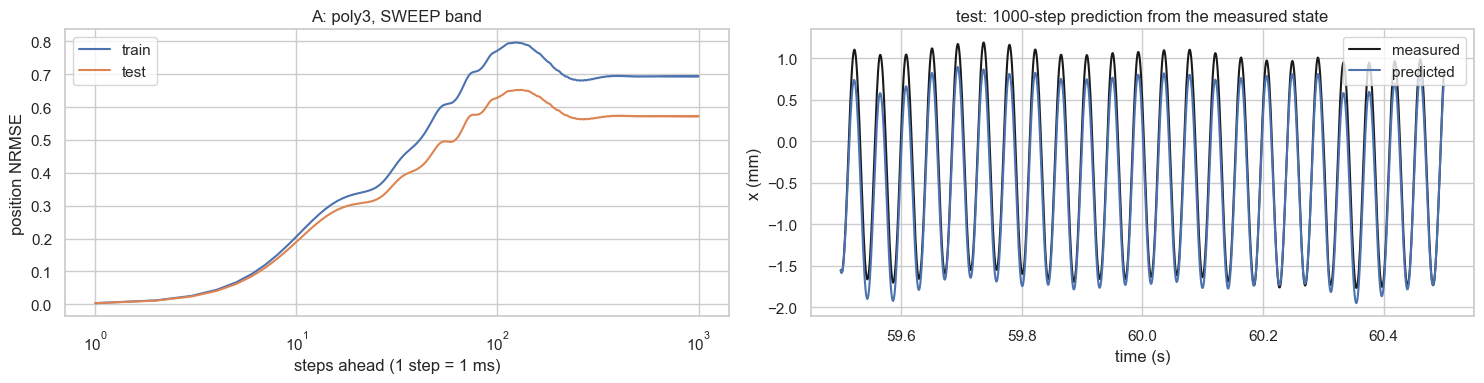

In [5]:
evaluate("A: poly3", poly3, p_p3, "chirpsched", "sweep", H=1000)

## Method B: cubic spring with the datasheet motor constant shape, LLS

Method A's model, but the motor constant follows the shape of the actuator datasheet curve, $K_f(z) = 283 - 0.0198\,z - 0.578\,z^2$ (N/A, $z$ in mm). Only its scale $\Gamma_0$ is fitted, so the motor term cannot take over the role of the spring. Same data and weighting as Method A.

$$m\ddot{x} = \Gamma_0\, s(x)\, i - c\,\dot{x} - (k_1 x + k_2 x^2 + k_3 x^3), \qquad s(x) = \frac{K_f(x)}{283} \;(= 1 \text{ at the centre})$$

$\Gamma_0$ and $c$ are fitted together with the spring ($c \geq 0$). Always: the datasheet shape $s(x)$, and $k_3 \geq 0$, so the spring hardens with stroke.

In [6]:
d, sel = DATA["chirpsched"]["train"], DATA["chirpsched"]["train"]["sweep"]
x, i, v = d["x"][sel], d["i"][sel], d["v"][sel]
w = 1 / np.abs(signal.hilbert(d["i"]))[sel]                          # 1 / current amplitude, so every part of the sweep counts about equally
cols = {"Gamma0": i * s_ds(x), "c": -v, "k1": -x, "k2": -x**2, "k3": -x**3}   # m a = Gamma0 s(x) i - c v - (k1 x + k2 x^2 + k3 x^3)
y = M * d["a"][sel]
A = np.column_stack(list(cols.values()))
lb = [0.0 if n in ("c", "k3") else -np.inf for n in cols]           # c >= 0; k3 >= 0: hardening spring
sc = np.linalg.norm(A * w[:, None], axis=0)                          # column scaling
q = dict(zip(cols, lsq_linear(A * w[:, None] / sc, y * w, bounds=(lb, np.inf)).x / sc))
G0, c = q.pop("Gamma0"), q.pop("c")
p_B = np.r_[G0, c, list(q.values())]
poly3_ds = lambda x, u, q, G0=G0: q[0] * x + q[1] * x**2 + q[2] * x**3 + G0 * (1 - s_ds(x)) * u   # spring, plus Gamma0 (1 - s(x)) i so the motor force is Gamma0 s(x) i
print(f"Gamma0 = {G0:.1f} N/A, c = {c:.1f} N s/m; " + ", ".join(f"{n} = {val:.4g}" for n, val in q.items()))
print("Gamma(x)/Gamma0 at -5, +5 mm (datasheet shape): " + ", ".join(f"{s_ds(xx):.3f}" for xx in (-5e-3, 5e-3)))

Gamma0 = 199.2 N/A, c = 1574.7 N s/m; k1 = 4.094e+04, k2 = 2.329e+06, k3 = 8.177e-07
Gamma(x)/Gamma0 at -5, +5 mm (datasheet shape): 0.949, 0.949


train NRMSE at k = 1, 10, 100, 1000: 0.003, 0.208, 0.849, 0.910
test  NRMSE at k = 1, 10, 100, 1000: 0.003, 0.192, 0.771, 0.797


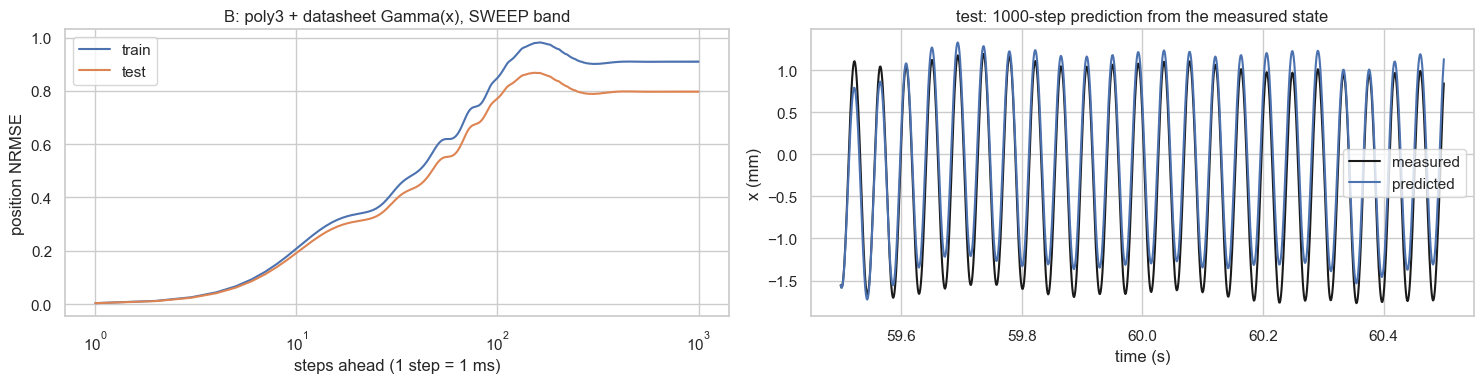

In [7]:
evaluate("B: poly3 + datasheet Gamma(x)", poly3_ds, p_B, "chirpsched", "sweep", H=1000)

## Method C: unequal magnets with a position-dependent motor constant, LLS

Two repelling magnets with their own strength, $C_R, C_L \geq 0$ (PDF eq. 3 with $Q_R \neq Q_L$): each always repels, and the net spring always restores and stiffens with stroke. $C_R \neq C_L$ gives the asymmetry. The gap is fixed at the measured $g_0$ = `G00` = 22.3 mm, so the model is linear in $C_R, C_L$. The motor constant is linear in position, $\Gamma(x) = \Gamma + \Gamma_1 x$, as in Method A, with $\Gamma_1$ fitted. Same data and weighting as Method A.

$$m\ddot{x} = (\Gamma + \Gamma_1 x)\, i - c\,\dot{x} - \left(\frac{C_R}{(g_0 - x)^3} - \frac{C_L}{(g_0 + x)^3}\right)$$

$\Gamma$, $c$, $\Gamma_1$, $C_R$ and $C_L$ are fitted together ($c \geq 0$). Always: $g_0$ = 22.3 mm, and $C_R, C_L \geq 0$.

In [8]:
d, sel = DATA["chirpsched"]["train"], DATA["chirpsched"]["train"]["sweep"]
x, i, v = d["x"][sel], d["i"][sel], d["v"][sel]
w = 1 / np.abs(signal.hilbert(d["i"]))[sel]                          # 1 / current amplitude, so every part of the sweep counts about equally
cols = {"Gamma": i, "c": -v, "Gamma1": x * i, "C_R": -1 / (G00 - x)**3, "C_L": 1 / (G00 + x)**3}   # m a = (Gamma + Gamma1 x) i - c v - (C_R / (g0 - x)^3 - C_L / (g0 + x)^3)
y = M * d["a"][sel]
A = np.column_stack(list(cols.values()))
lb = [-np.inf if n in ("Gamma", "Gamma1") else 0.0 for n in cols]   # c, C_R, C_L >= 0
sc = np.linalg.norm(A * w[:, None], axis=0)                          # column scaling
q = dict(zip(cols, lsq_linear(A * w[:, None] / sc, y * w, bounds=(lb, np.inf)).x / sc))
G, c, G1, C_R, C_L = q.values()
p_C = np.r_[G, c, G1, C_R, C_L]
magnets = lambda x, u, q: q[1] / (G00 - x)**3 - q[2] / (G00 + x)**3 - q[0] * x * u   # magnets, minus Gamma1 x i so the motor force is (Gamma + Gamma1 x) i
print(f"Gamma = {G:.1f} N/A, c = {c:.1f} N s/m; Gamma1 = {G1:.4g} N/(A m); C_R = {C_R:.4g} N m^3, C_L = {C_L:.4g} N m^3 "
      f"(C_R / C_L = {C_R / C_L:.3f}; PDF guess C_mu = {CMU0} N m^2)")
print(f"stiffness at x = 0: {3 * (C_R + C_L) / G00**4:.3g} N/m, force at x = 0: {(C_R - C_L) / G00**3:.3g} N")   # dF/dx = 3 C_R / (g0 - x)^4 + 3 C_L / (g0 + x)^4
print("Gamma(x)/Gamma at -5, +5 mm: " + ", ".join(f"{1 + G1 * xx / G:.3f}" for xx in (-5e-3, 5e-3)))

Gamma = 200.9 N/A, c = 1586.3 N s/m; Gamma1 = 3573 N/(A m); C_R = 0.001604 N m^3, C_L = 0.001574 N m^3 (C_R / C_L = 1.019; PDF guess C_mu = 2.423 N m^2)
stiffness at x = 0: 3.86e+04 N/m, force at x = 0: 2.65 N
Gamma(x)/Gamma at -5, +5 mm: 0.911, 1.089


train NRMSE at k = 1, 10, 100, 1000: 0.003, 0.206, 0.760, 0.710
test  NRMSE at k = 1, 10, 100, 1000: 0.003, 0.190, 0.616, 0.577


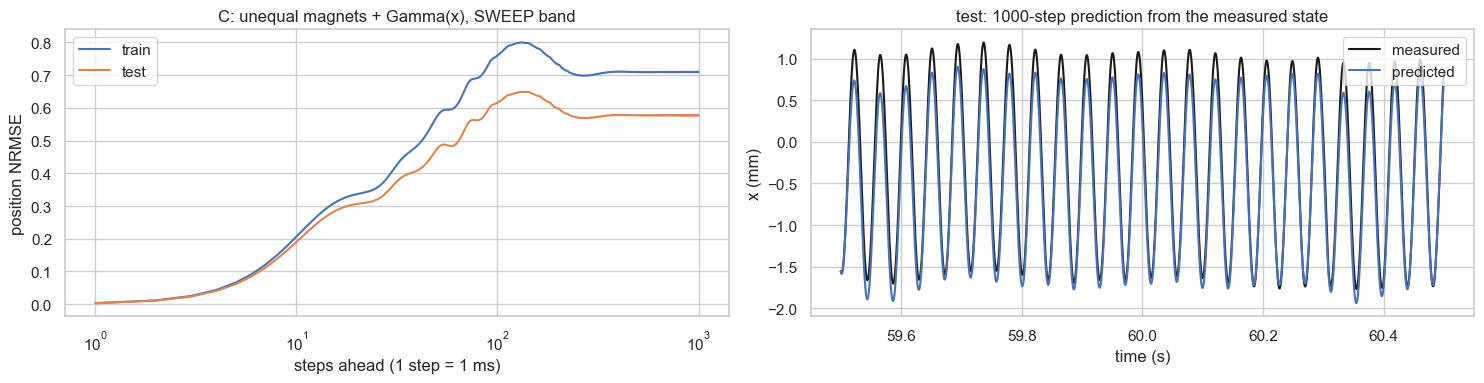

In [9]:
evaluate("C: unequal magnets + Gamma(x)", magnets, p_C, "chirpsched", "sweep", H=1000)

## Validation

Each row starts all three models from the same measured state and predicts the position over a short window, on data the fits did not use: other parts of the test scheduled chirp, a plain chirp, and two September runs (another day, other amplitudes). The NRMSE over the window is in the legend. The PRBS run moves ±16 mm, far outside the ±6 mm the models were fitted on, so that row is an extrapolation test.

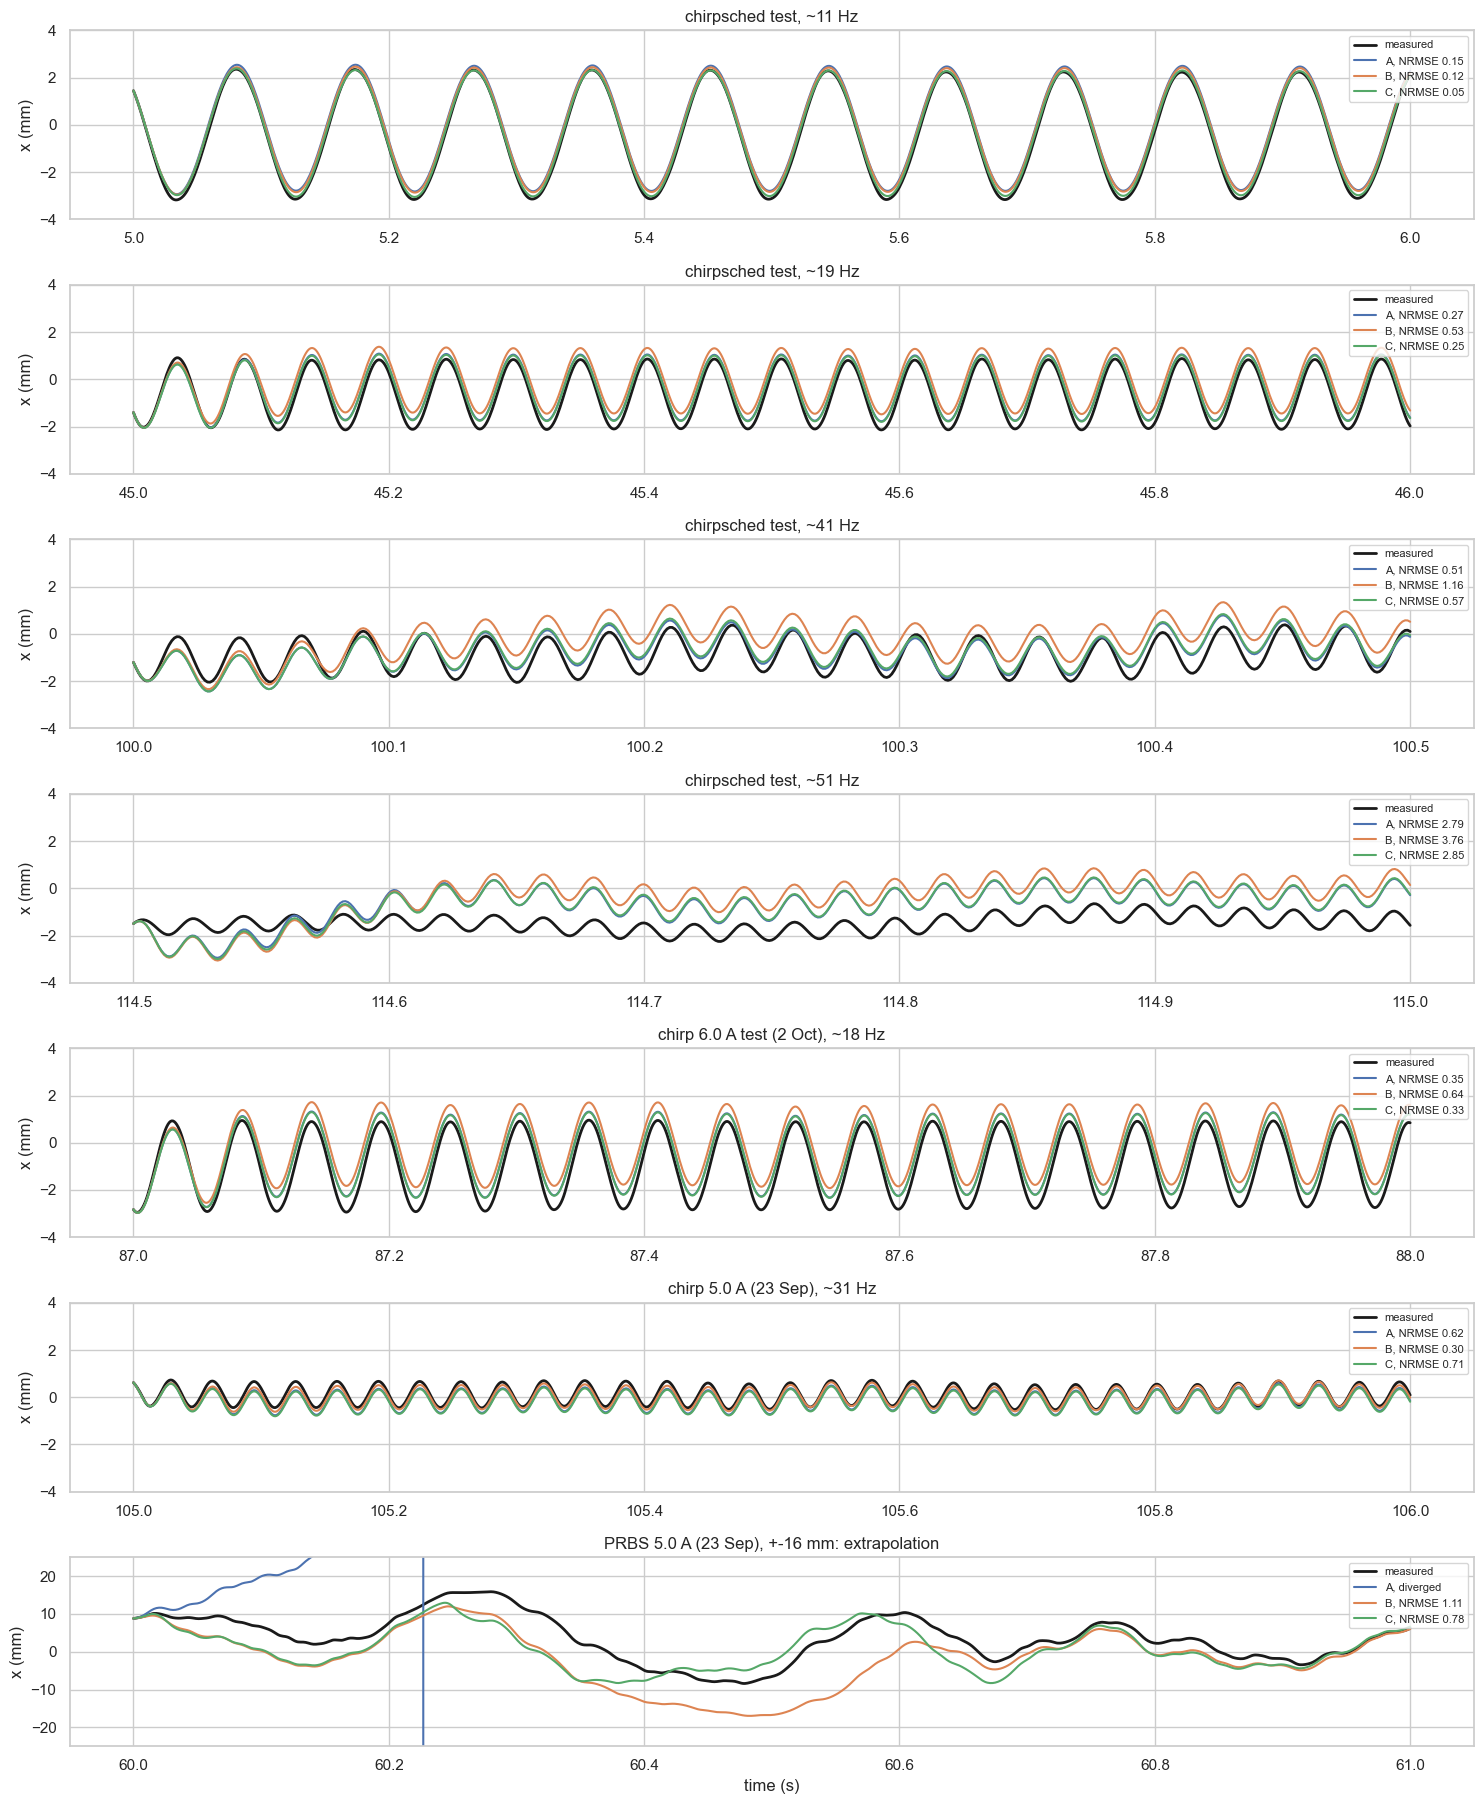

In [10]:
MODELS = [("A", poly3, p_p3), ("B", poly3_ds, p_B), ("C", magnets, p_C)]
SEP = lambda name: load(next(Path("data").glob(f"voice_coil_log_{name}_*.csv")))   # September logs in data/
VAL = [  # (label, data, start s, length s); chirp frequency f0 (f1/f0)^(t/T), checked against the current's zero crossings
    ("chirpsched test, ~11 Hz", DATA["chirpsched"]["test"], 5.0, 1.0),       # 10.7-10.9 Hz
    ("chirpsched test, ~19 Hz", DATA["chirpsched"]["test"], 45.0, 1.0),      # 19.0-19.2 Hz
    ("chirpsched test, ~41 Hz", DATA["chirpsched"]["test"], 100.0, 0.5),     # 41.4-41.7 Hz
    ("chirpsched test, ~51 Hz", DATA["chirpsched"]["test"], 114.5, 0.5),     # 50.9-51.2 Hz
    ("chirp 6.0 A test (2 Oct), ~18 Hz", DATA["chirp"]["test"], 87.0, 1.0),  # 18.3-18.9 Hz
    ("chirp 5.0 A (23 Sep), ~31 Hz", SEP("chirp_5.0A"), 105.0, 1.0),         # 30.7-31.7 Hz (this chirp ends at 50 Hz)
    ("PRBS 5.0 A (23 Sep), +-16 mm: extrapolation", SEP("prbs"), 60.0, 1.0),
]
Y_LIM, Y_LIM_PRBS = 4.0, 25.0                           # mm, y range of the chirp rows and of the PRBS row
fig, ax = plt.subplots(len(VAL), 1, figsize=(15, 2.6 * len(VAL)))
for a_, (label, d, t0, T) in zip(ax, VAL):
    s, H = np.array([np.searchsorted(d["t"], t0)]), int(round(T / TS))
    t, xm = d["t"][s[0]:s[0] + H + 1], target(d, s, H)[0]
    sns.lineplot(x=t, y=xm * 1e3, ax=a_, color="k", lw=2, label="measured")
    for name, Fs, p in MODELS:
        with np.errstate(all="ignore"):
            xp = rollout(Fs, p, d, s, H)[0]
        nr = np.sqrt(np.mean((xp - xm) ** 2)) / np.std(xm)
        sns.lineplot(x=t, y=np.where(np.isfinite(xp), xp, np.nan) * 1e3, ax=a_, lw=1.5, label=f"{name}, NRMSE {nr:.2f}" if np.isfinite(nr) else f"{name}, diverged")
    lim = Y_LIM_PRBS if label.startswith("PRBS") else Y_LIM
    a_.set(title=label, ylabel="x (mm)", ylim=(-lim, lim))
    a_.legend(loc="upper right", fontsize=8)
ax[-1].set(xlabel="time (s)")
plt.tight_layout(); plt.show()

## Kalman filter with Method C, on the raw 2 kHz data

Extended Kalman filter (EKF) on the Method C model, state $z = [x, \dot{x}]$, input $i$, measurement $y = x$:

$$z_{k+1} = f_{\text{RK4}}(z_k, i_k) + w_k, \qquad y_k = x_k + e_k$$

**Real-time conditions.** The filter sees the signals as a controller would: the raw log at 2 kHz ($T_s$ = 0.5 ms), the commanded current and the laser position straight from the CSV. No low-pass, no 50/150 Hz notch, no `TAU`/`TAU_ACC` shift, no decimation. Only the model parameters come from the offline fit.

- Predict: one RK4 step of the model (the same `step` as the fits, at 0.5 ms); covariance with the Jacobian $F = I + A T_s + (A T_s)^2/2$ of the model linearised at the current state.
- Process noise $w$: white acceleration noise with std `SIG_A`, set to the Method C acceleration residual on its fit data. Measurement noise $e$: std `SIG_Y`, the raw laser std in the idle window ($t < 0$, actuator at rest; tuning knob). It is mostly 50/150 Hz mains pickup, so not white.
- The velocity is the filter's own causal estimate.

**Single-step prediction error** $y_k - \hat{x}_{k|k-1}$ (the innovation: measurement minus the prediction made before that measurement is used), on the fit run (**TRAIN**, blue) and on two runs the fit did not use (**TEST**, red); the first `T_SETTLE` s are left out while the filter converges.
- Figure 1: error against time, with ±2 predicted std. Printed: RMS, NRMSE, and innovation std / predicted std (1 when `SIG_A` and `SIG_Y` are consistent with the data).
- Figure 2: measured $y_k$ and the one-step prediction $\hat{x}_{k|k-1}$ against time, whole run and a `ZOOM_KF` s zoom mid-run.
- Figure 3: histogram of the error, with the normal density the filter predicts. A shifted or wider histogram on TEST than on TRAIN shows model error on new data.
- Figure 4: PSD of the error (Welch, 2 kHz), with the flat level of white noise at the predicted std. An optimal filter has white innovations; peaks show dynamics the model misses or coloured measurement noise (the 50/150 Hz mains lines).

SIG_A = 7.86 m/s^2 (Method C residual), SIG_Y = 0.0766 mm (raw laser, idle window)
[TRAIN] chirpsched train (fit data)  RMS 0.1180 mm, NRMSE 9.55e-02; innovation std / predicted std = 1.39
[TEST ] chirpsched test              RMS 0.1148 mm, NRMSE 9.16e-02; innovation std / predicted std = 1.35
[TEST ] chirp 6.0 A test (2 Oct)     RMS 1.3680 mm, NRMSE 1.29e-01; innovation std / predicted std = 16.20


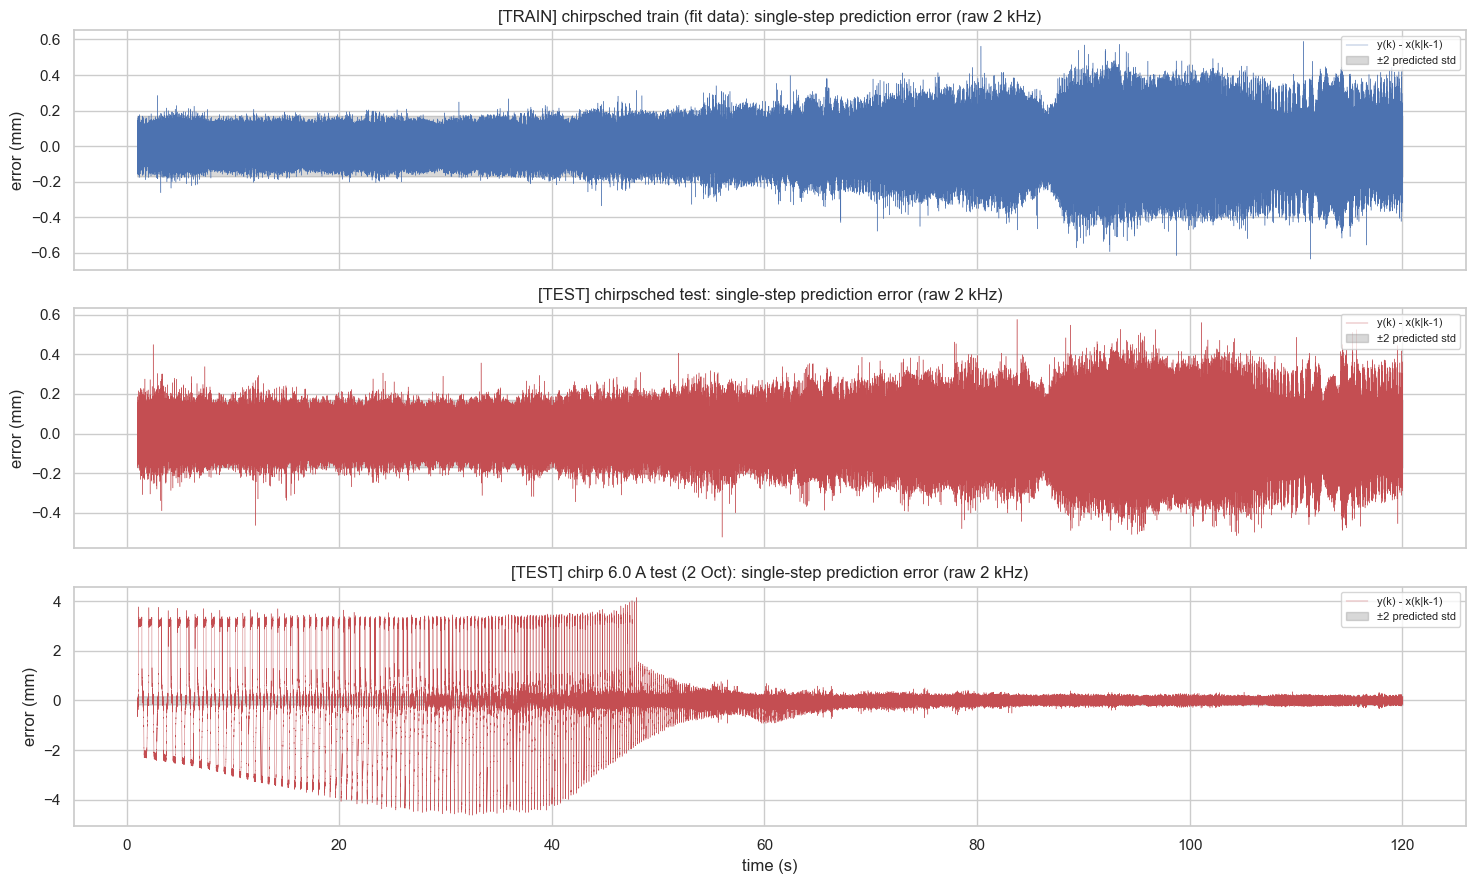

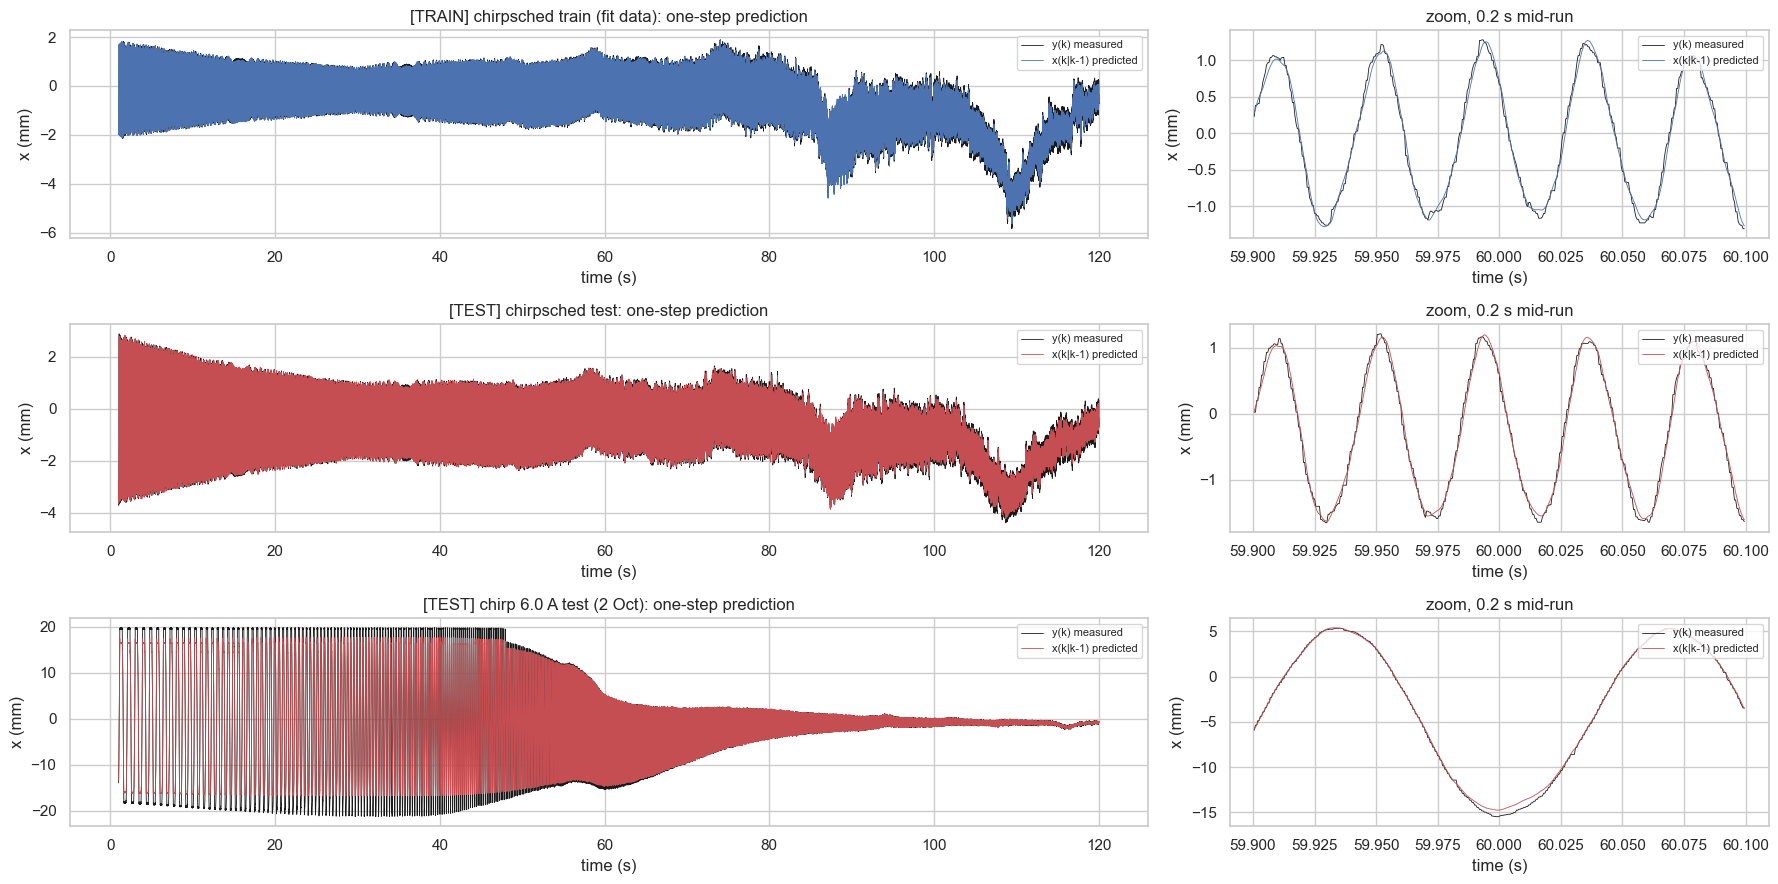

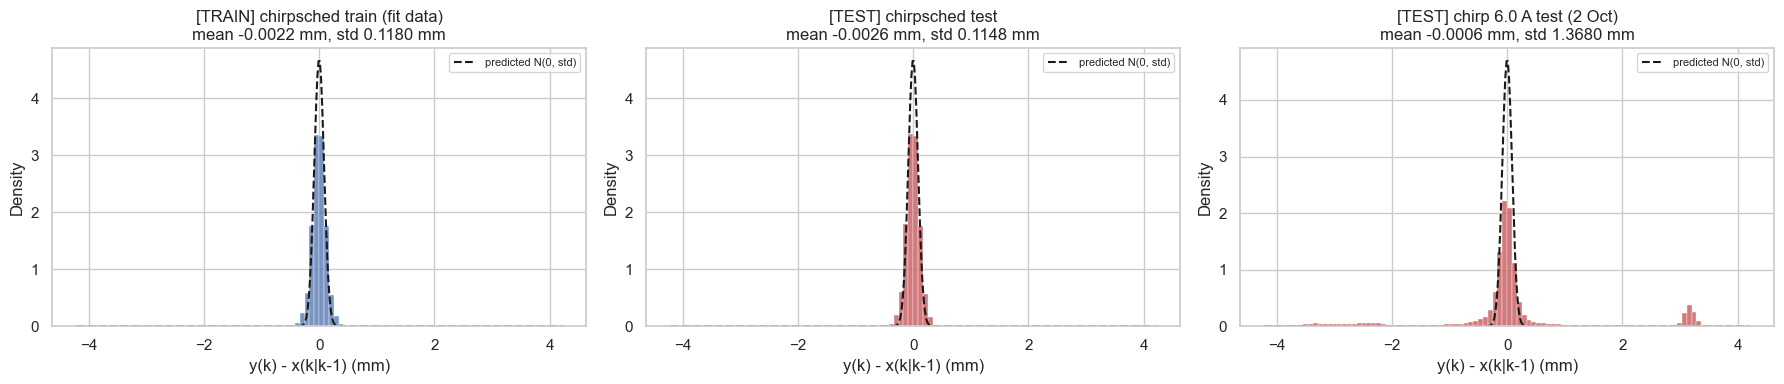

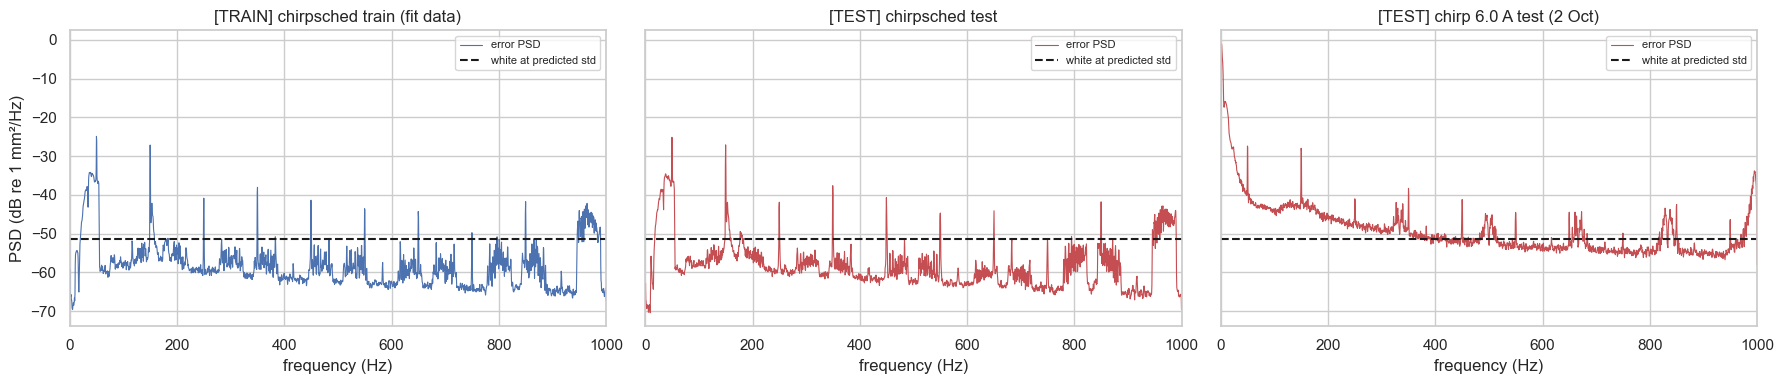

In [11]:
T_SETTLE = 1.0                                          # s left out at the start while the filter converges
TS_RAW = 1 / FS_LOG                                     # s, the filter runs at the logged 2 kHz


def load_raw(path):
    "Raw 2 kHz log as a real-time filter sees it: commanded current and laser position, no low-pass, notch, TAU shift or decimation."
    raw = np.loadtxt(path, delimiter=",", skiprows=2)
    idle = raw[raw[:, 0] < 0.0, 11] * 1e-3              # t < 0: actuator at rest, so this is pure measurement noise
    raw = raw[raw[:, 0] >= 0.0]
    return dict(t=raw[:, 0], i=raw[:, 2], x=raw[:, 11] * 1e-3, sig_idle=np.std(idle))


RAW = {(exp, s): load_raw(next(Path("data", s).glob(f"voice_coil_log_{exp}_*.csv"))) for exp in ("chirpsched", "chirp") for s in ("train", "test")}
d, sel = DATA["chirpsched"]["train"], DATA["chirpsched"]["train"]["sweep"]
acc_C = lambda x, v, u: (p_C[0] * u - p_C[1] * v - magnets(x, u, p_C[2:])) / M
SIG_A = np.std(d["a"][sel] - acc_C(d["x"][sel], d["v"][sel], d["i"][sel]))   # m/s^2, process noise: Method C residual on its fit data
SIG_Y = RAW["chirpsched", "train"]["sig_idle"]          # m, measurement noise std: raw laser at rest (knob; mostly 50/150 Hz mains pickup, not white)
print(f"SIG_A = {SIG_A:.3g} m/s^2 (Method C residual), SIG_Y = {SIG_Y * 1e3:.4f} mm (raw laser, idle window)")


def ekf(Fs, p, d, sig_a, sig_y, ts=TS):
    "Extended Kalman filter at sample time ts, state [x, v], measurement x. Returns filtered x, v, one-step predicted x(k|k-1) and its innovation std."
    acc = lambda x, v, u: (p[0] * u - p[1] * v - Fs(x, u, p[2:])) / M
    q11, q12, q22, R = sig_a**2 * ts**4 / 4, sig_a**2 * ts**3 / 2, sig_a**2 * ts**2, sig_y**2   # white acceleration noise, discretized
    y, i = d["x"].tolist(), d["i"].tolist()             # python floats: the scalar loop runs several times faster
    n = len(y)
    xf, vf, xp, sp = (np.empty(n) for _ in range(4))
    x, v, p11, p12, p22 = y[0], 0.0, R, 0.0, 1e-4      # start at the first measurement, at rest, velocity std 1 cm/s
    for k in range(n):
        if k:   # predict: RK4 step of the model; covariance F P F' + Q with F = I + A Ts + (A Ts)^2 / 2
            u = i[k - 1]
            x, v = step(x, v, u, i[k] if FOH else u, acc, ts)
            a21, a22 = -(Fs(x + 1e-7, u, p[2:]) - Fs(x - 1e-7, u, p[2:])) / 2e-7 / M, -p[1] / M   # A = [[0, 1], [a21, a22]]
            f11, f12 = 1 + a21 * ts**2 / 2, ts + a22 * ts**2 / 2
            f21, f22 = a21 * ts + a21 * a22 * ts**2 / 2, 1 + a22 * ts + (a21 + a22**2) * ts**2 / 2
            g11, g12, g21, g22 = f11 * p11 + f12 * p12, f11 * p12 + f12 * p22, f21 * p11 + f22 * p12, f21 * p12 + f22 * p22   # F P
            p11, p12, p22 = g11 * f11 + g12 * f12 + q11, g11 * f21 + g12 * f22 + q12, g21 * f21 + g22 * f22 + q22
        xp[k], S = x, p11 + R
        sp[k] = np.sqrt(S)
        k1, k2, e = p11 / S, p12 / S, y[k] - x           # update with the measured position
        x, v = x + k1 * e, v + k2 * e
        p11, p12, p22 = p11 - k1 * p11, p12 - k1 * p12, p22 - k2 * p12
        xf[k], vf[k] = x, v
    return xf, vf, xp, sp


# self-check: on noise-free output of the model itself, the one-step prediction must converge to it
_d = DATA["chirpsched"]["test"]
_x = rollout(magnets, p_C, _d, np.array([0]), 3000)[0]
assert np.abs(ekf(magnets, p_C, dict(x=_x, i=_d["i"][:3001]), SIG_A, SIG_Y)[2] - _x)[1000:].max() < 1e-6

# single-step prediction error e = y(k) - x(k|k-1) on the raw fit run (TRAIN) and two raw runs the fit did not use (TEST)
rms = lambda e: np.sqrt(np.mean(e**2))
RUNS = [("TRAIN", "chirpsched train (fit data)", RAW["chirpsched", "train"]),
        ("TEST", "chirpsched test", RAW["chirpsched", "test"]),
        ("TEST", "chirp 6.0 A test (2 Oct)", RAW["chirp", "test"])]
ERR, PRED = [], []
fig, ax = plt.subplots(len(RUNS), 1, figsize=(15, 3 * len(RUNS)), sharex=True)
for a_, (split, label, d) in zip(ax, RUNS):
    xf, vf, xp, sp = ekf(magnets, p_C, d, SIG_A, SIG_Y, TS_RAW)
    band = d["t"] >= T_SETTLE
    e = (d["x"] - xp)[band]
    ERR.append((split, label, e, np.mean(sp[band])))
    PRED.append((split, label, d, xp))
    print(f"[{split:5s}] {label:28s} RMS {rms(e) * 1e3:.4f} mm, NRMSE {rms(e) / np.std(d['x'][band]):.2e}; "
          f"innovation std / predicted std = {np.std(e) / np.mean(sp[band]):.2f}")
    color = "C0" if split == "TRAIN" else "C3"
    sns.lineplot(x=d["t"][band], y=e * 1e3, ax=a_, lw=0.3, color=color, label="y(k) - x(k|k-1)")
    a_.fill_between(d["t"][band], -2e3 * sp[band], 2e3 * sp[band], color="0.5", alpha=0.3, label="±2 predicted std")
    a_.set(ylabel="error (mm)", title=f"[{split}] {label}: single-step prediction error (raw 2 kHz)")
    a_.legend(loc="upper right", fontsize=8)
ax[-1].set(xlabel="time (s)")
plt.tight_layout(); plt.show()

# time series: measured x(k) and the one-step prediction x(k|k-1); left the whole run, right a ZOOM_KF s window mid-run
ZOOM_KF = 0.2                                           # s, length of the zoom window
fig, ax = plt.subplots(len(PRED), 2, figsize=(18, 3 * len(PRED)), gridspec_kw=dict(width_ratios=(2, 1)))
for row, (split, label, d, xp) in zip(ax, PRED):
    t_mid = d["t"][len(d["t"]) // 2]
    for a_, m in [(row[0], d["t"] >= T_SETTLE), (row[1], np.abs(d["t"] - t_mid) <= ZOOM_KF / 2)]:
        sns.lineplot(x=d["t"][m], y=d["x"][m] * 1e3, ax=a_, lw=0.6, color="k", label="y(k) measured")
        sns.lineplot(x=d["t"][m], y=xp[m] * 1e3, ax=a_, lw=0.6, color="C0" if split == "TRAIN" else "C3", label="x(k|k-1) predicted")
        a_.set(xlabel="time (s)", ylabel="x (mm)")
        a_.legend(loc="upper right", fontsize=8)
    row[0].set(title=f"[{split}] {label}: one-step prediction")
    row[1].set(title=f"zoom, {ZOOM_KF} s mid-run")
plt.tight_layout(); plt.show()

# histogram of the single-step error, with the normal density the filter predicts (std = mean innovation std)
lim = max(np.percentile(np.abs(e), 99.5) for *_, e, _ in ERR) * 1e3
fig, ax = plt.subplots(1, len(ERR), figsize=(6 * len(ERR), 4), sharex=True)
for a_, (split, label, e, s) in zip(ax, ERR):
    sns.histplot(e * 1e3, ax=a_, stat="density", bins=np.linspace(-lim, lim, 101), color="C0" if split == "TRAIN" else "C3")
    g = np.linspace(-lim, lim, 400)
    a_.plot(g, np.exp(-0.5 * (g / (s * 1e3))**2) / (s * 1e3 * np.sqrt(2 * np.pi)), "k--", label="predicted N(0, std)")
    a_.set(xlabel="y(k) - x(k|k-1) (mm)", title=f"[{split}] {label}\nmean {e.mean() * 1e3:.4f} mm, std {e.std() * 1e3:.4f} mm")
    a_.legend(fontsize=8)
plt.tight_layout(); plt.show()

# PSD of the single-step error (Welch, fs = 2 kHz). An optimal filter has white innovations: flat at 2 std^2 / fs (one-sided);
# peaks show structure the model misses (e.g. the 35.5 Hz laser-mount mode) or coloured measurement noise (50/150 Hz mains)
fig, ax = plt.subplots(1, len(ERR), figsize=(6 * len(ERR), 4), sharey=True)
for a_, (split, label, e, s) in zip(ax, ERR):
    f, P = signal.welch(e * 1e3, fs=FS_LOG, window="hann", nperseg=4096, noverlap=2048, detrend="constant", scaling="density")
    sns.lineplot(x=f, y=10 * np.log10(P + 1e-20), ax=a_, lw=0.8, color="C0" if split == "TRAIN" else "C3", label="error PSD")
    a_.axhline(10 * np.log10(2 * (s * 1e3)**2 * TS_RAW), color="k", ls="--", label="white at predicted std")
    a_.set(xlim=(0, FS_LOG / 2), xlabel="frequency (Hz)", ylabel="PSD (dB re 1 mm²/Hz)", title=f"[{split}] {label}")
    a_.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Sliding-mode control on the Method C plant (clean, no noise)

A first look at the nominal sliding-mode controller. The plant is the fitted Method C model itself. The continuous-time control law is evaluated every $T_s$ = 0.5 ms (2 kHz) and held over the step (ZOH), and the plant is integrated with the same RK4 `step` as the fits.

**Plant.** Method C written as $\ddot x = f(x,\dot x) + g(x)\,u$, with $u = i$:

$$f(x,\dot x) = -\frac{c}{m}\,\dot x - \frac{1}{m}\left(\frac{C_R}{(g_0 - x)^3} - \frac{C_L}{(g_0 + x)^3}\right), \qquad g(x) = \frac{\Gamma + \Gamma_1 x}{m}$$

**Error system.** For a reference $r(t)$, $z_1 = x - r$ and $z_2 = \dot z_1 = \dot x - \dot r$:

$$\dot z_1 = z_2, \qquad \dot z_2 = f(x,\dot x) + g(x)\,u - \ddot r$$

**Sliding surface.**

$$s = a\,z_1 + z_2, \qquad a > 0$$

On $s = 0$, $\dot z_1 = -a z_1$, so $z_1 \to 0$ with time constant $1/a$. The derivative along the trajectories is

$$\dot s = \frac{\partial s}{\partial z}\,\dot z = \begin{bmatrix} a & 1 \end{bmatrix}\begin{bmatrix} z_2 \ f + g u - \ddot r \end{bmatrix} = a\,z_2 + f(x,\dot x) + g(x)\,u - \ddot r$$

**Reaching law with boundary layer.**

$$\dot s = -\eta\,\theta(s), \qquad \eta > 0, \qquad \theta(s) = \operatorname{sat}\!\left(\frac{s}{\phi}\right) = \begin{cases} 1 & s > \phi \ s/\phi & |s| \le \phi \ -1 & s < -\phi \end{cases}$$

**Control law.** Set the two expressions for $\dot s$ equal and solve for $u$:

$$\boxed{\,u = \frac{1}{g(x)}\Big(\ddot r - a\,(\dot x - \dot r) - f(x,\dot x) - \eta\,\operatorname{sat}\!\big(s/\phi\big)\Big)\,}$$

Inside the layer, $\dot z_1 = -a z_1 + s$ with $|s| \le \phi$, so $|z_1| \le \phi / a$ in steady state.

**Reference.** A linear chirp from $F_0$ = 1 Hz to $F_1$ = 20 Hz over $T_\text{r}$ = 30 s, then 10 s at $F_1$. $A$ = 2 mm, and $k = (F_1 - F_0)/T_\text{r}$:

$$\varphi(t) = \begin{cases} 2\pi\left(F_0 t + \tfrac{k}{2} t^2\right) & t < T_\text{r} \ 2\pi\left(F_0 T_\text{r} + \tfrac{k}{2} T_\text{r}^2 + F_1 (t - T_\text{r})\right) & t \ge T_\text{r} \end{cases}, \qquad \dot\varphi = 2\pi f(t), \qquad \ddot\varphi = \begin{cases} 2\pi k & t < T_\text{r} \ 0 & t \ge T_\text{r} \end{cases}$$

$$r = A \sin\varphi, \qquad \dot r = A\,\dot\varphi \cos\varphi, \qquad \ddot r = A\left(\ddot\varphi \cos\varphi - \dot\varphi^2 \sin\varphi\right)$$

Starting at 1 Hz rather than 0 keeps $s(0) = -\dot r(0) \approx -0.013$ m/s inside the layer.

**Parameters.**
- $a = 3\omega = 3 \cdot 2\pi \cdot 20 \approx 377$ s⁻¹, using the final frequency. It is fixed for the whole run.
- $\phi = a \cdot 0.05$ mm $\approx 0.019$ m/s, so $|z_1| \le \phi / a = 0.05$ mm inside the layer.
- $\eta = 2\,\sigma_a \approx 16$ m/s², where $\sigma_a$ = `SIG_A` is the Method C acceleration residual on its fit data (Kalman filter cell). Why this value:
  - $\eta$ must be larger than the model error as it appears in $\dot s$, which has units of acceleration. $\sigma_a$ is that error as measured, and $2\sigma_a$ covers about 95 % of it. The clean plant here has no model error, but the value is already right for the real actuator.
  - Inside the layer, $\dot s = -(\eta/\phi)\,s$, a pole at $\lambda = \eta/\phi \approx 830$ rad/s ≈ 2.2 $a$. The $s$-loop is faster than the $z_1$-loop, so the two do not interact.
  - Sampling: $\lambda T_s \approx 0.42$ and $a T_s \approx 0.19$, both well below 1. The sampled boundary-layer dynamics stay monotone, so the continuous-time law can be used at 2 kHz without a discrete-time redesign.

**Corrections to the handwritten derivation.**
1. $\dot s = a z_2 + (f + g u - \ddot r)$, not $(a+1)(f + g u - \ddot r)$. As a result, the $1/(a+1)$ factor on $\eta\theta$ goes away and the term $-a z_2$ appears.
2. $\dot z_2$ contains $\ddot r$. For a sine this is $-A\omega^2 \sin\omega t$, not $A\omega\cos\omega t$ (which is $\dot r$).
3. $f$ depends on $\dot x$ through the damping term.

**Check.** The cell also runs with $\eta = 0$, which leaves only the model cancellation. On the clean plant this alone is not exact, because the ZOH holds $u$ over the step, and with $\eta = 0$ nothing pulls $s$ back. The sampling error accumulates to about 0.2 mm, against about 0.003 mm with $\eta$. The dashed lines at ±6 A mark the current used in the experiments. $u$ is not saturated here, and the 20 Hz, 2 mm reference needs about 8 A.

eta = 15.72 m/s^2: max |x - r| = 0.0062 mm (hold 0.0026 mm), max |s/phi| = 0.667, max |u| = 8.26 A, RMS u (hold) = 5.64 A
eta =  0.00 m/s^2: max |x - r| = 0.2122 mm (hold 0.2122 mm), max |s/phi| = 4.265, max |u| = 8.33 A, RMS u (hold) = 5.67 A


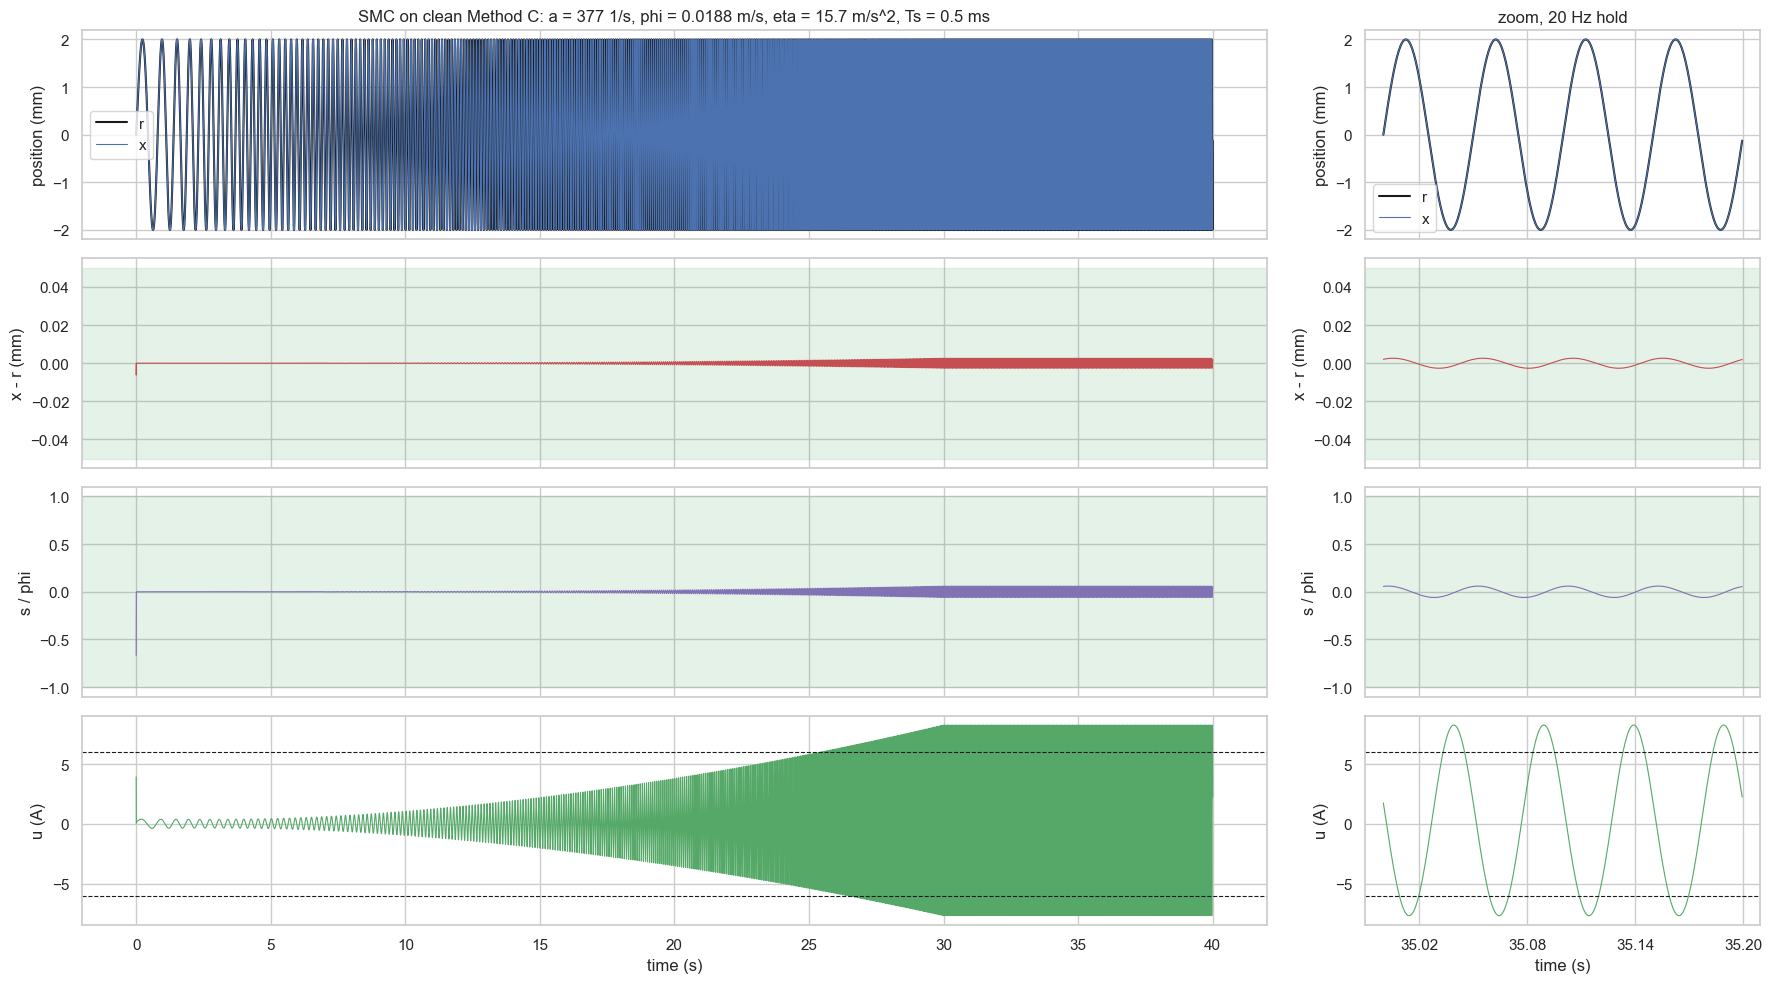

: 

In [ ]:
A_REF, F0, F1, T_RAMP, T_HOLD = 2e-3, 1.0, 20.0, 30.0, 10.0   # m, Hz, Hz, s, s: chirp F0 -> F1 in T_RAMP, then T_HOLD at F1
TS_C = 1 / FS_LOG                                             # s, controller and plant step: 2 kHz
A_SMC = 3 * 2 * np.pi * F1                                    # 1/s, surface slope a = 3*omega at the FINAL frequency
PHI = A_SMC * 0.05e-3                                         # m/s, boundary layer: |z1| <= PHI / a = 0.05 mm inside it
ETA = 2 * SIG_A                                               # m/s^2, reaching gain: 2x the Method C acceleration residual (knob)
I_LIM = 6.0                                                   # A, reference line only: the current used in the experiments, u is not saturated

# chirp reference, analytic: phase ph, its rate dph = 2 pi f(t) and acceleration ddph
t = np.arange(0.0, T_RAMP + T_HOLD, TS_C)
kf, ramp = (F1 - F0) / T_RAMP, t < T_RAMP
ph = 2 * np.pi * np.where(ramp, F0 * t + kf * t**2 / 2, F0 * T_RAMP + kf * T_RAMP**2 / 2 + F1 * (t - T_RAMP))
dph, ddph = 2 * np.pi * np.where(ramp, F0 + kf * t, F1), np.where(ramp, 2 * np.pi * kf, 0.0)
r, rd, rdd = A_REF * np.sin(ph), A_REF * dph * np.cos(ph), A_REF * (ddph * np.cos(ph) - dph**2 * np.sin(ph))


def smc(eta):
    "Sliding-mode loop on the clean Method C plant, continuous law with ZOH at TS_C. Returns x, s / PHI and u."
    n = len(t)
    xs, ss, us = np.empty(n), np.empty(n), np.empty(n)
    x, v = 0.0, 0.0                                     # start at rest in the centre
    for k in range(n):
        z1, z2 = x - r[k], v - rd[k]
        s = A_SMC * z1 + z2
        u = (rdd[k] - A_SMC * z2 - acc_C(x, v, 0.0) - eta * min(max(s / PHI, -1.0), 1.0)) / ((p_C[0] + p_C[2] * x) / M)   # f = acc_C(x, v, 0), g = (Gamma + Gamma1 x) / m
        xs[k], ss[k], us[k] = x, s / PHI, u
        x, v = step(x, v, u, u, acc_C, TS_C)            # plant: RK4 of Method C, input held over the step
    return xs, ss, us


hold = t >= T_RAMP
for eta in (ETA, 0.0):                                  # eta = 0: feedforward / cancellation only
    xs, ss, us = smc(eta)
    print(f"eta = {eta:5.2f} m/s^2: max |x - r| = {np.abs(xs - r).max() * 1e3:.4f} mm (hold {np.abs(xs - r)[hold].max() * 1e3:.4f} mm), "
          f"max |s/phi| = {np.abs(ss).max():.3f}, max |u| = {np.abs(us).max():.2f} A, RMS u (hold) = {np.sqrt(np.mean(us[hold]**2)):.2f} A")
xs, ss, us = smc(ETA)

fig, ax = plt.subplots(4, 2, figsize=(18, 10), sharex="col", gridspec_kw=dict(width_ratios=[3, 1]))
zoom = (t >= T_RAMP + T_HOLD / 2) & (t < T_RAMP + T_HOLD / 2 + 0.2)   # 0.2 s mid-hold, 20 Hz
for col, m in enumerate((slice(None), zoom)):
    sns.lineplot(x=t[m], y=r[m] * 1e3, ax=ax[0, col], lw=1.5, color="k", label="r")
    sns.lineplot(x=t[m], y=xs[m] * 1e3, ax=ax[0, col], lw=0.8, color="C0", label="x").set(ylabel="position (mm)")
    sns.lineplot(x=t[m], y=(xs - r)[m] * 1e3, ax=ax[1, col], lw=0.8, color="C3").set(ylabel="x - r (mm)")
    ax[1, col].axhspan(-PHI / A_SMC * 1e3, PHI / A_SMC * 1e3, color="C2", alpha=0.15)   # boundary-layer bound phi / a
    sns.lineplot(x=t[m], y=ss[m], ax=ax[2, col], lw=0.8, color="C4").set(ylabel="s / phi")
    ax[2, col].axhspan(-1, 1, color="C2", alpha=0.15)
    sns.lineplot(x=t[m], y=us[m], ax=ax[3, col], lw=0.8, color="C2").set(xlabel="time (s)", ylabel="u (A)")
    for lim in (-I_LIM, I_LIM):
        ax[3, col].axhline(lim, color="k", ls="--", lw=0.8)
ax[0, 0].set(title=f"SMC on clean Method C: a = {A_SMC:.0f} 1/s, phi = {PHI:.4f} m/s, eta = {ETA:.1f} m/s^2, Ts = {TS_C * 1e3:.1f} ms")
ax[0, 1].set(title="zoom, 20 Hz hold"); ax[3, 1].xaxis.set_major_locator(plt.MaxNLocator(4))
plt.tight_layout(); plt.show()